# Importing  libraries

In [34]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Reading Data

In [35]:
# Check if running in Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    csv_path = '/content/drive/MyDrive/Grokking Machine Learning/02- Python Data Analysis/01- Titanic Data Analysis Project/titanic_train.csv'
else: 
    csv_path = 'titanic_train.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
df = pd.read_csv(csv_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploring Data

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
# Drop Unnecessary columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [39]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
# Check Missing Values
round(df.isna().mean() * 100 ,2)

Survived     0.00
Pclass       0.00
Sex          0.00
Age         19.87
SibSp        0.00
Parch        0.00
Fare         0.00
Embarked     0.22
dtype: float64

* Missing Values can be dropped or imputed. 
* If Missing Values are less than 5% of the total data, we can drop ***Rows***.
* If Missing Values are more than 40% of the total data, we can drop ***Column***.
* Otherwise, we can impute them 
        
        ( Not a rule of thumb, but a good practice)

In [41]:
df.columns = df.columns.str.lower()

In [42]:
df.sample()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
871,1,1,female,47.0,1,1,52.5542,S


In [43]:
X = df.drop(['survived', 'sibsp', 'parch', 'fare', 'embarked'], axis=1)
y = df['survived']

In [44]:
X.head()

,pclass,sex,age
0,3,male,22.0
1,1,female,38.0
2,3,female,26.0
3,1,female,35.0
4,3,male,35.0


# Preprocessing

In [45]:
# Convert Categorical to Numerical
X['sex'] = X['sex'].map({'female':0, 'male':1})

In [46]:
# Split the data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Knn Imputer
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [48]:
X_train

array([[ 1. ,  1. , 45.5],
       [ 2. ,  1. , 23. ],
       [ 3. ,  1. , 32. ],
       ...,
       [ 3. ,  1. , 41. ],
       [ 1. ,  0. , 14. ],
       [ 1. ,  1. , 21. ]])

# Default Decision Tree Classifier


Train Accuracy:  0.8778089887640449
Test Accuracy:  0.776536312849162


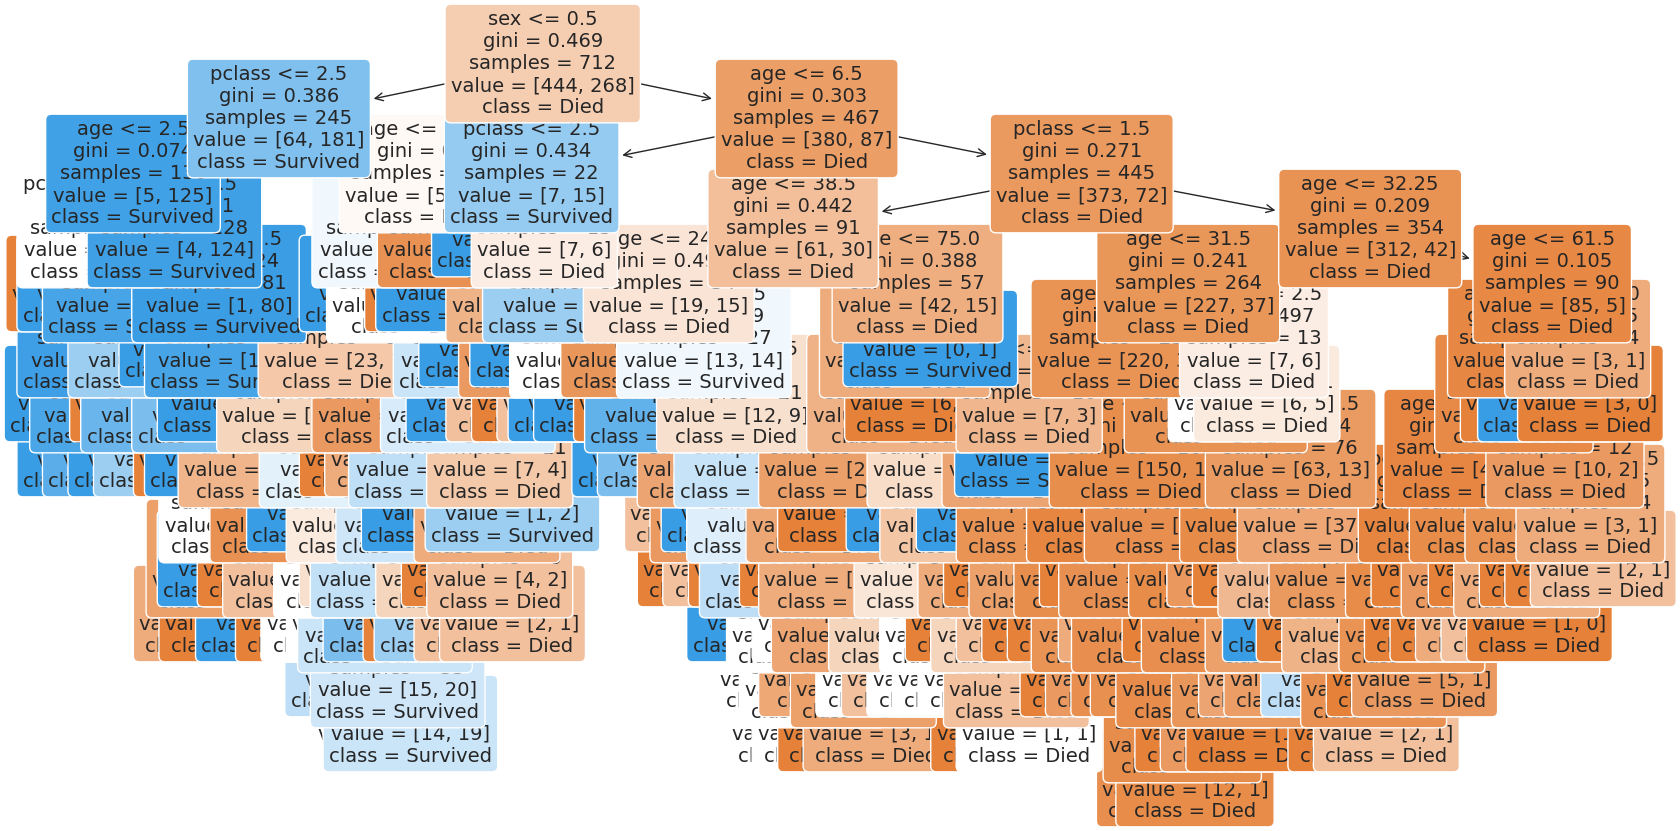

In [49]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()

# Train the model
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

# Visualize the Decision Tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()


# Entropy

 

* Range(0~1)

<img src="https://www.researchgate.net/publication/342520628/figure/fig2/AS:907606478553088@1593401655516/Graph-of-Binary-Cross-Entropy-Loss-Function-Here-Entropy-is-defined-on-Y-axis-and.ppm" width="400" height="350">

Train Accuracy:  0.8778089887640449
Test Accuracy:  0.776536312849162


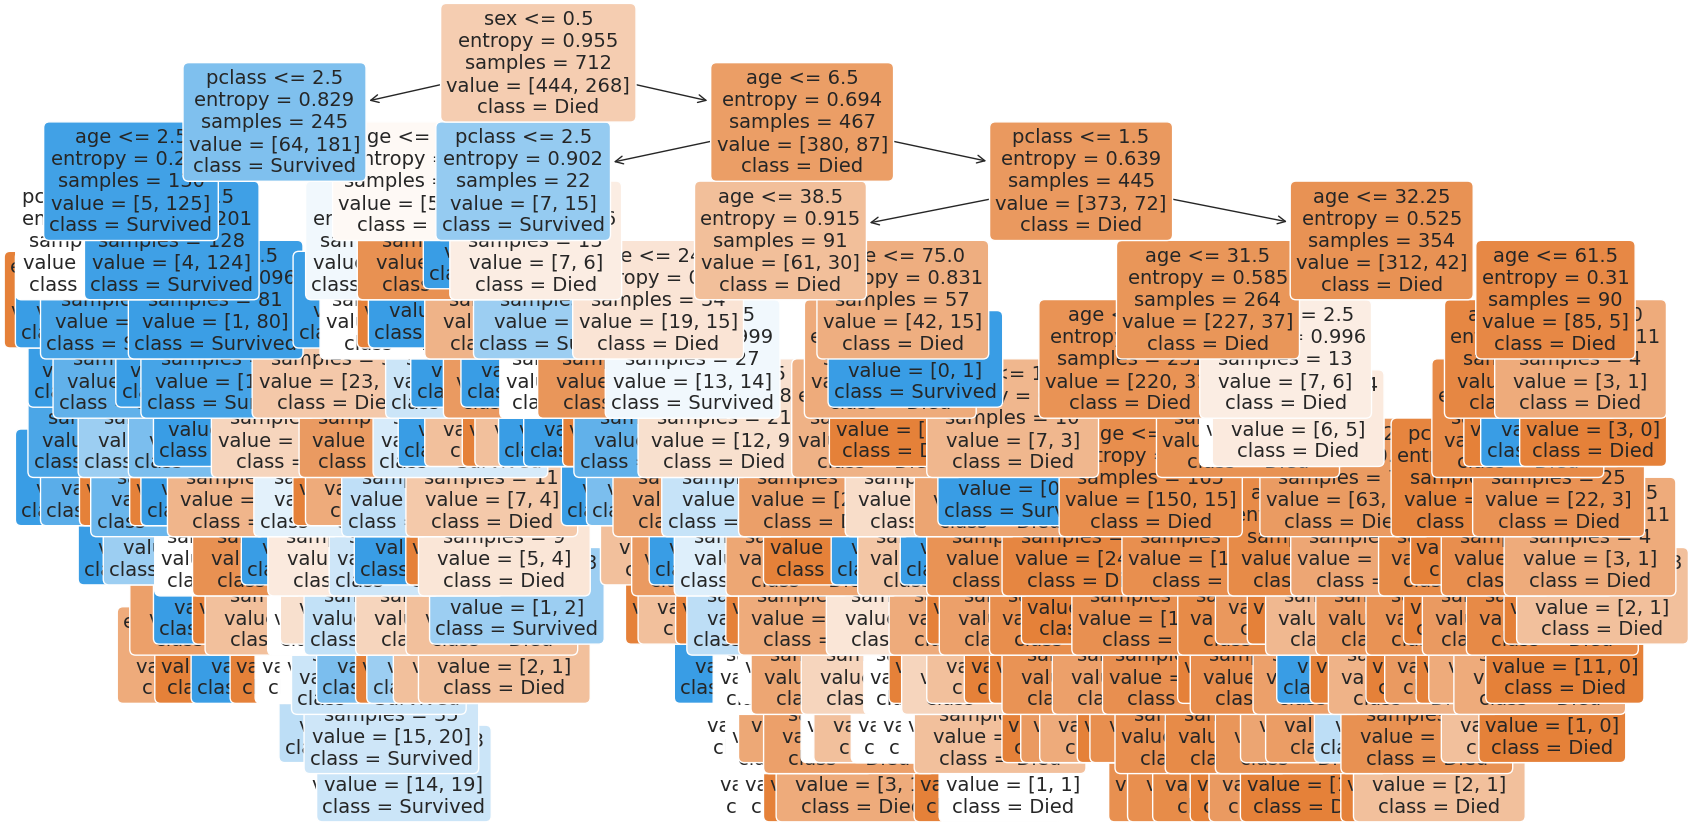

In [50]:
clf_entropy = DecisionTreeClassifier(criterion='entropy')
clf_entropy.fit(X_train, y_train)
y_pred = clf_entropy.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(20,10))
plot_tree(clf_entropy, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()

# Prunning

## Max_depth
* sklearn default value is None
* If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.


Train Accuracy:  0.8778089887640449
Test Accuracy:  0.7988826815642458


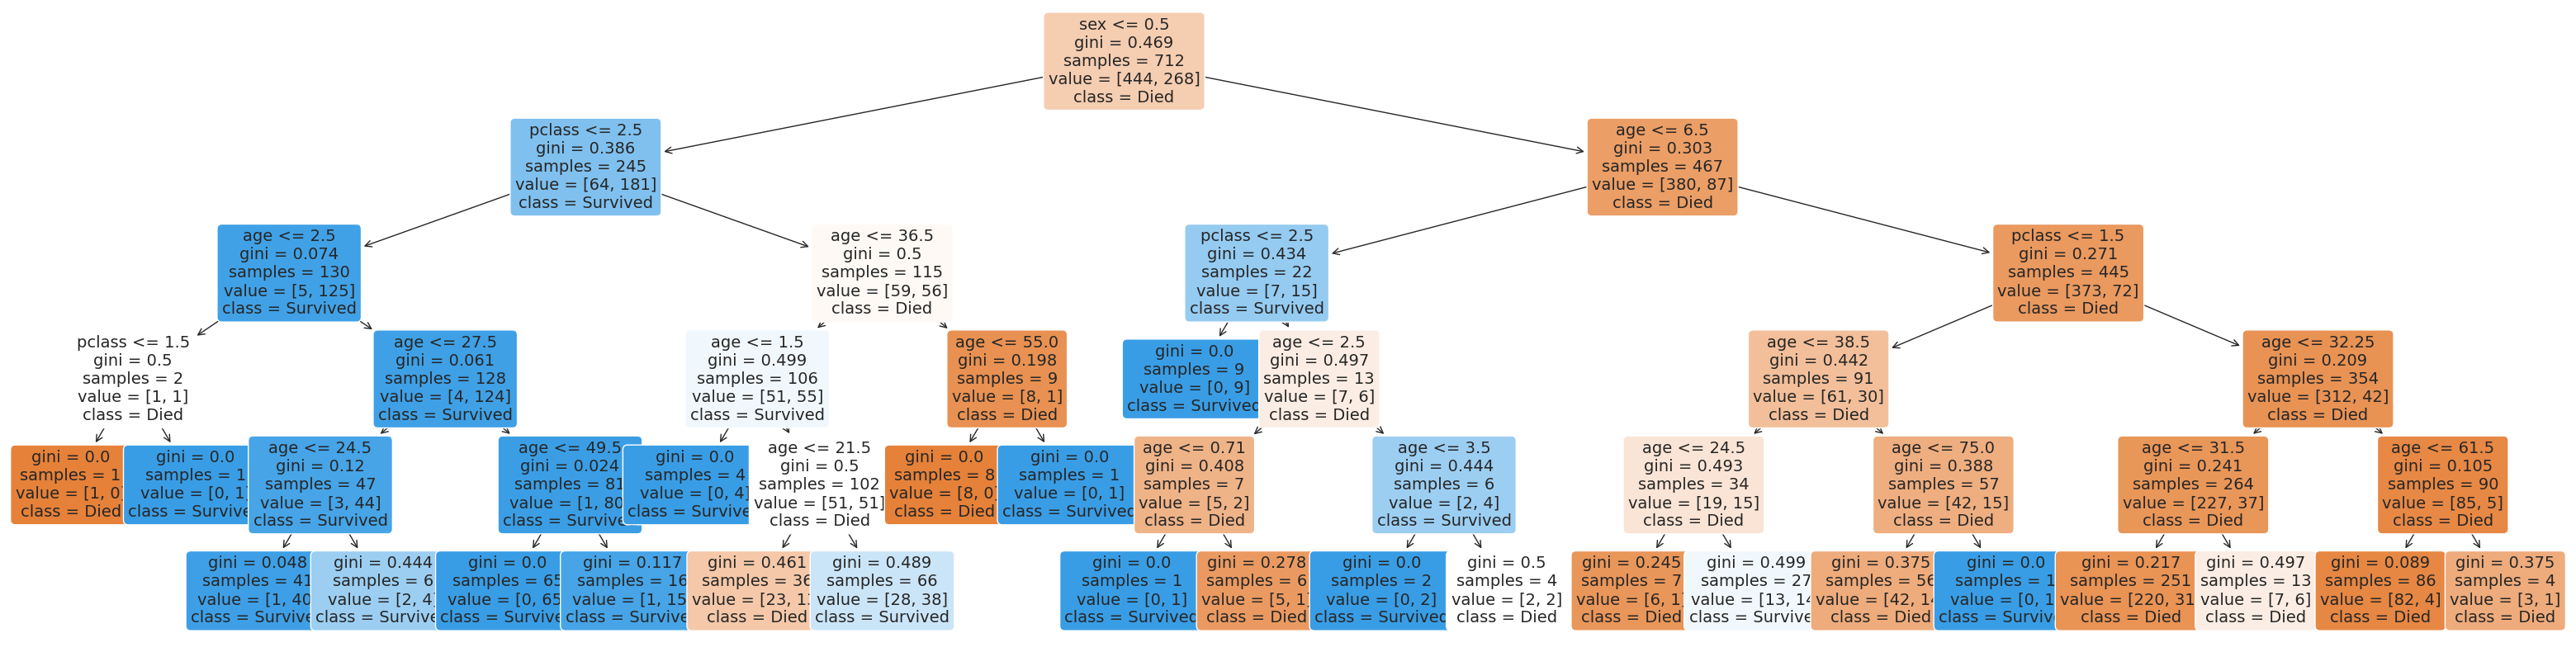

In [51]:
clf5 = DecisionTreeClassifier(max_depth=5)
clf5.fit(X_train, y_train)
y_pred = clf5.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(40,10))
plot_tree(clf5, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()

Train Accuracy:  0.8103932584269663
Test Accuracy:  0.8044692737430168


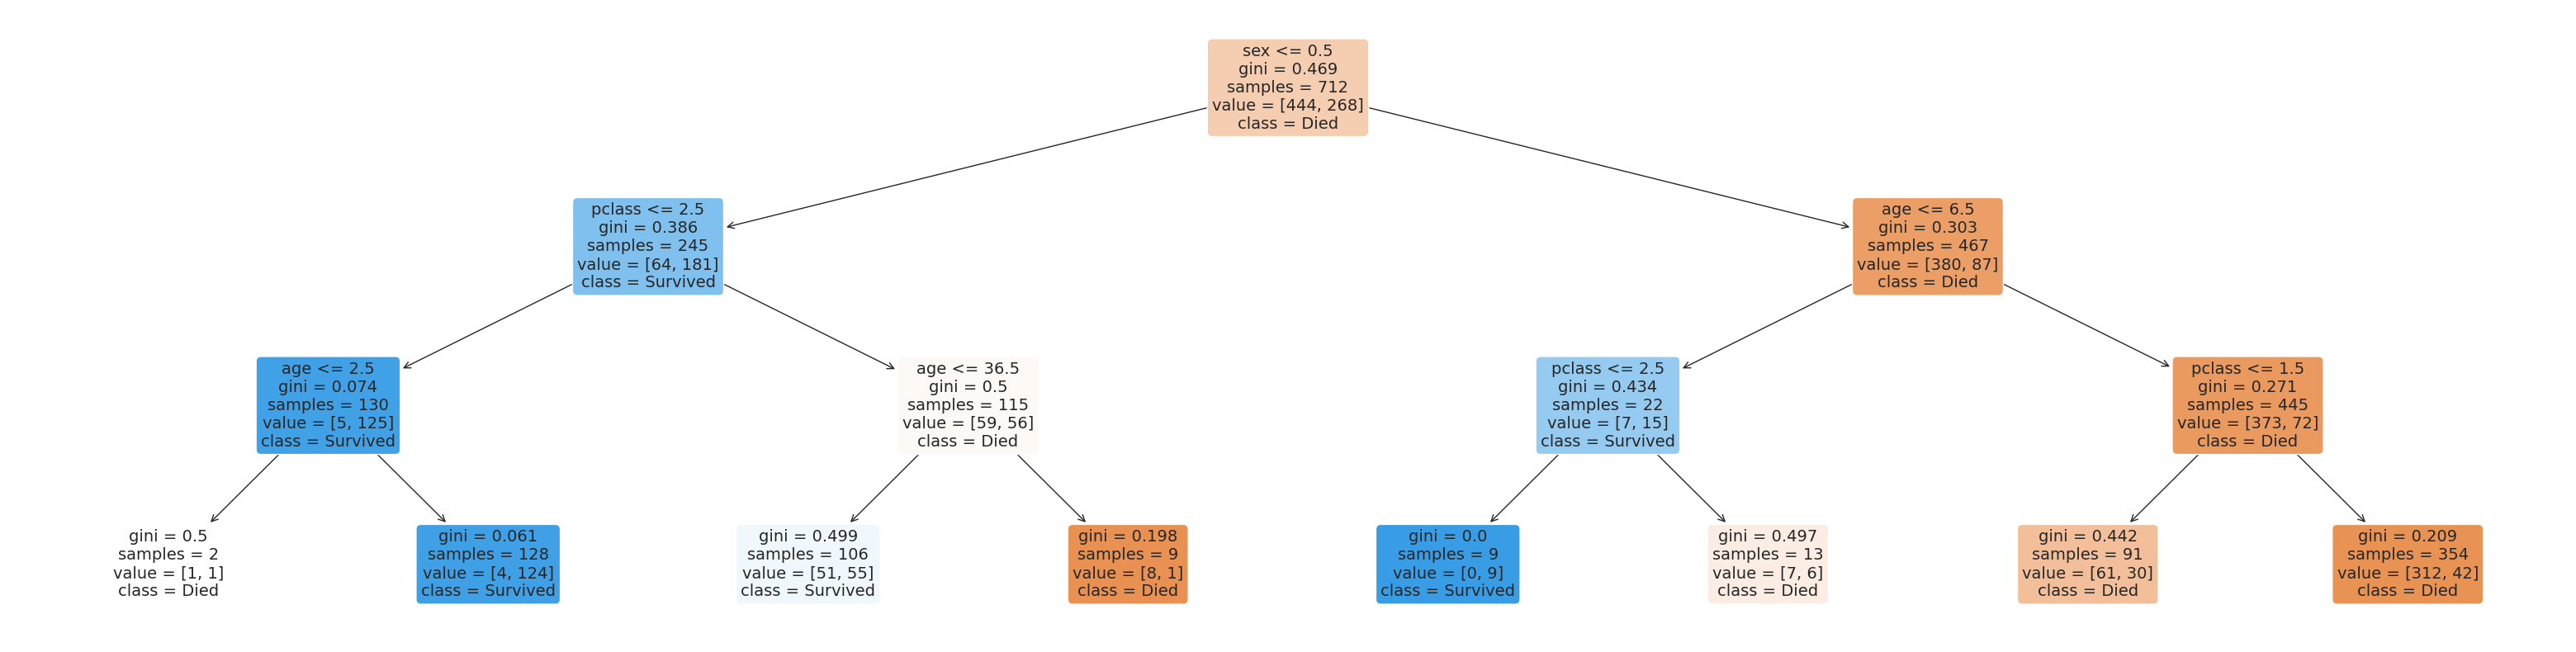

In [52]:
clf3 = DecisionTreeClassifier(max_depth=3)
clf3.fit(X_train, y_train)
y_pred = clf3.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf3.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(40,10))
plot_tree(clf3, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()

## min_samples_split 
* sklearn default=2
* The minimum number of samples required to split an internal node

Train Accuracy:  0.8230337078651685
Test Accuracy:  0.770949720670391


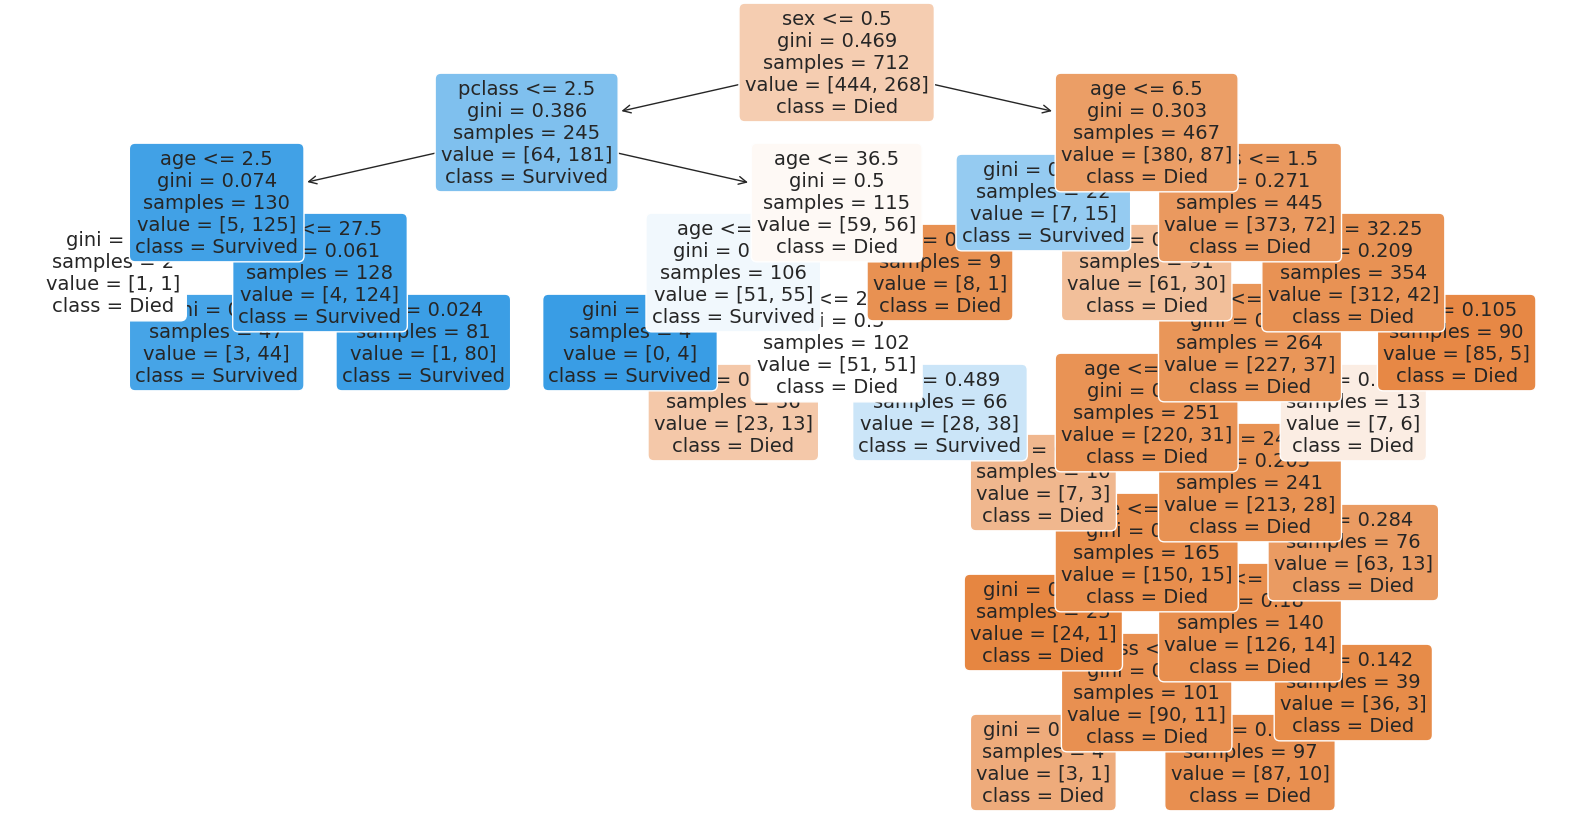

In [53]:
clf = DecisionTreeClassifier(min_samples_split=100)

# Train the model
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()
y_pred = clf.predict(X_test)



## min_samples_leaf
* sklearn default=1
* The minimum number of samples required to be at a leaf node

Train Accuracy:  0.7921348314606742
Test Accuracy:  0.7653631284916201


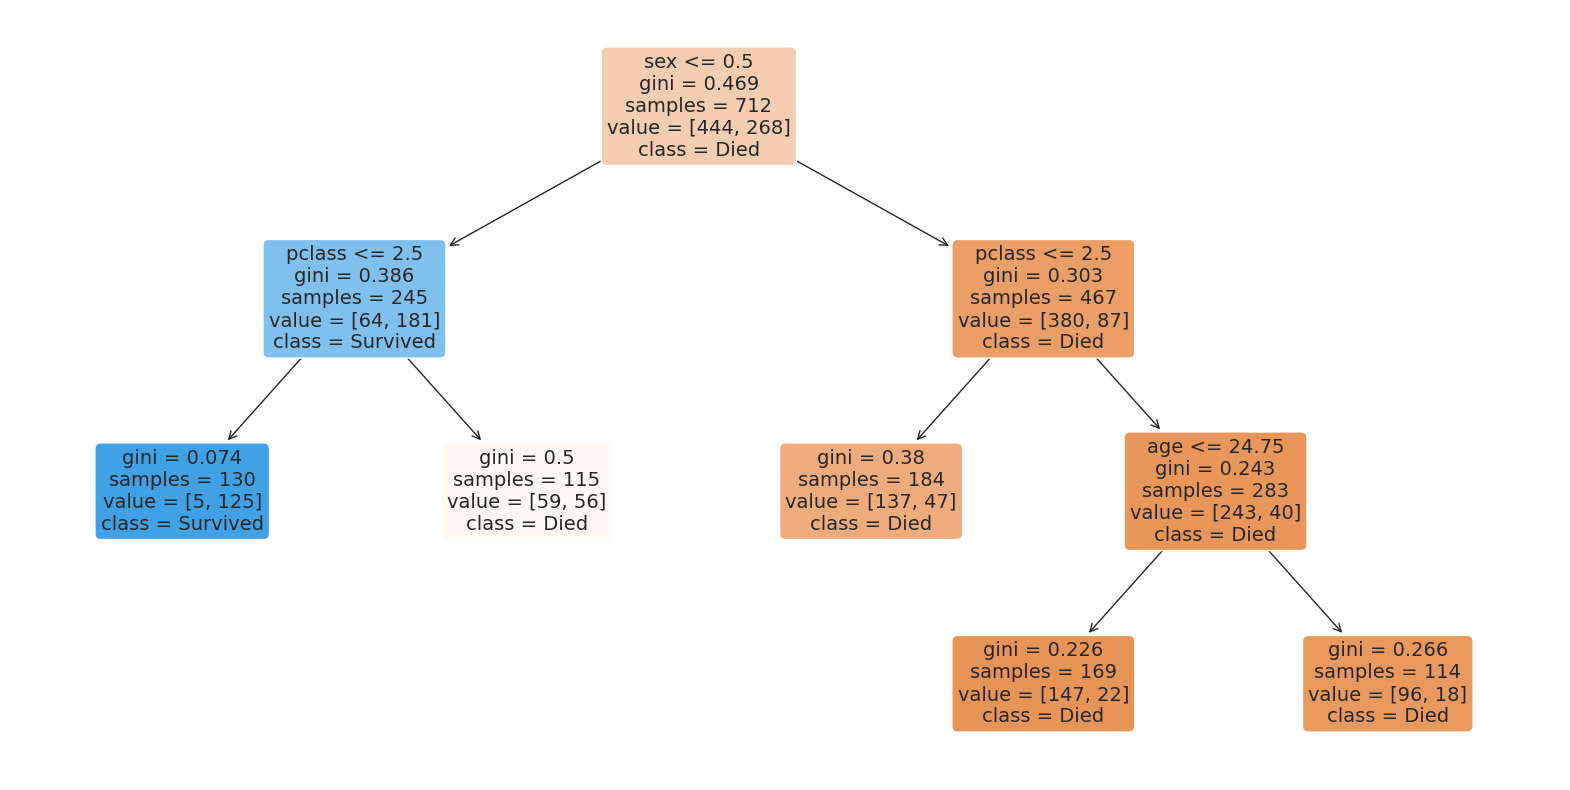

In [54]:
clf = DecisionTreeClassifier(min_samples_leaf=100)

# Train the model
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()
y_pred = clf.predict(X_test)

## min_impurity_decrease
* sklearn default=0.0
* A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

Train Accuracy:  0.8033707865168539
Test Accuracy:  0.7653631284916201


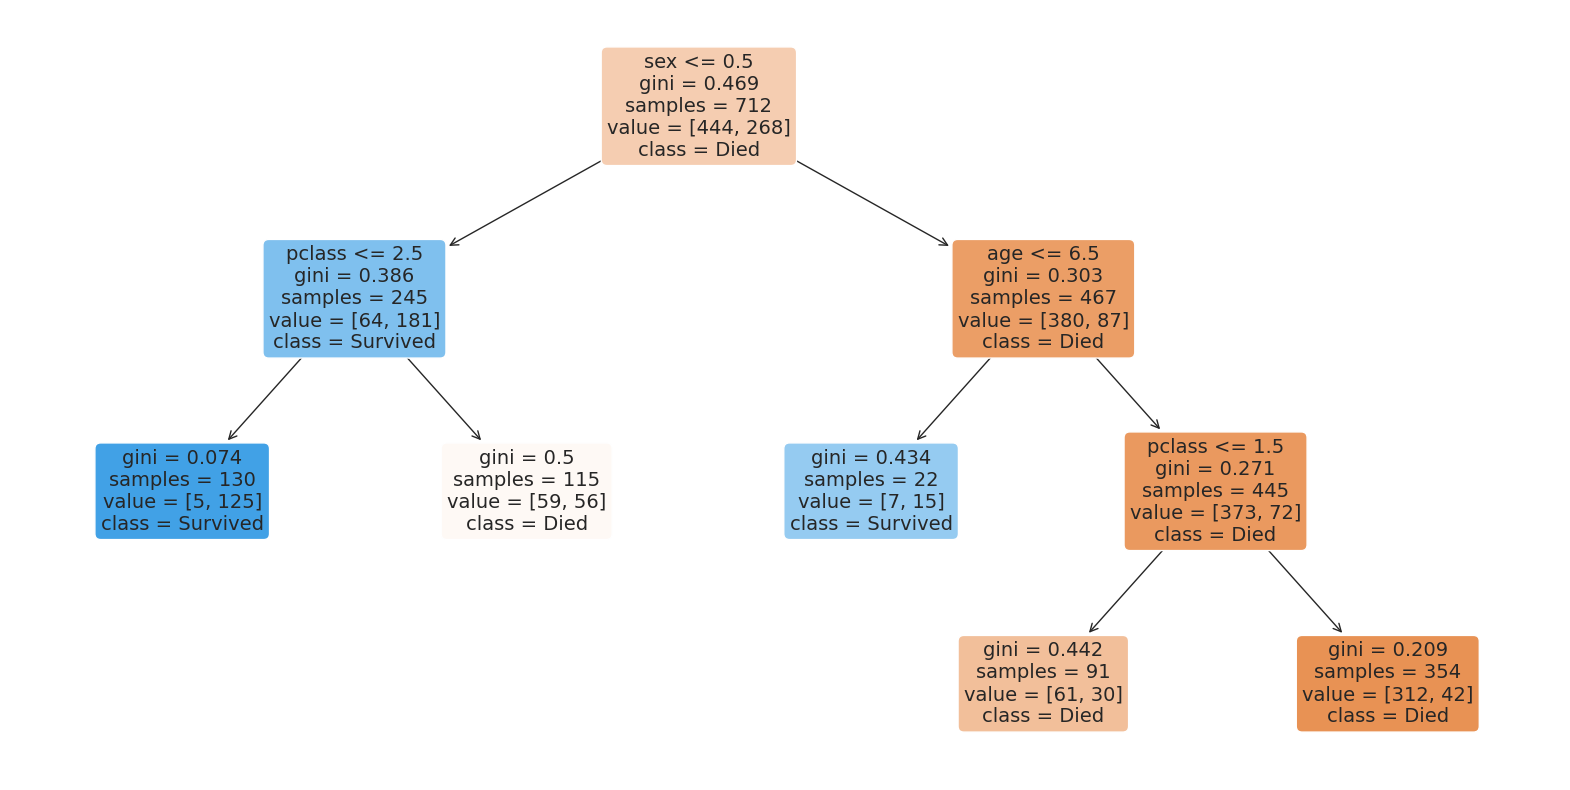

In [55]:
clf = DecisionTreeClassifier(min_impurity_decrease=0.005)

# Train the model
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Train Accuracy: ', accuracy_score(y_train, clf.predict(X_train)))
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=14)
plt.show()
y_pred = clf.predict(X_test)

# Output

In [56]:
X_new = {'pclass': 1, 'sex': 0, 'age': 35}
X_new = pd.DataFrame(X_new, index=[0])
X_new

,pclass,sex,age
0,1,0,35


In [57]:
X_new = imputer.transform(X_new)
X_new

array([[ 1.,  0., 35.]])

In [58]:
clf.predict(X_new)

array([1])

In [59]:
clf.predict_proba(X_new)

array([[0.03846154, 0.96153846]])

In [60]:
Probability_of_Surviving = clf.predict_proba(X_new) [0,1] * 100 
Probability_of_Surviving

96.15384615384616

# Feature Importance


* Normalized total reduction of criteria by feature (Gini importance).
* The higher, the more important the feature.

In [61]:
clf.feature_importances_

array([0.23668849, 0.68423038, 0.07908113])

<Axes: >

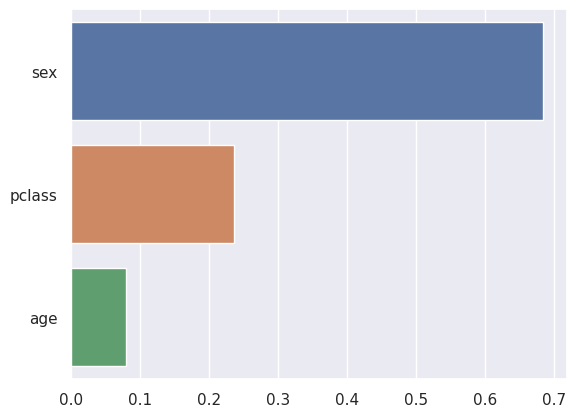

In [62]:
# plot feature importance in descending order
feature_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)


# Other Methods

In [63]:
clf.score(X_test, y_test)

0.7653631284916201

In [64]:
clf.get_depth()

3

In [65]:
clf.get_n_leaves()

5

In [66]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.005,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}